# Decision Tree — UNDERFIT (basic)

Notebook ini menunjukkan contoh **underfit** pada Decision Tree.

## Intuisi
- **Underfit** terjadi saat model terlalu sederhana untuk menangkap pola data.
- Pada Decision Tree, penyebab paling umum: `max_depth` terlalu kecil (mis. 1).

## Yang akan kamu lihat
- Akurasi **train** dan **test** sama-sama relatif rendah.
- Decision boundary terlihat terlalu simpel (kurang fleksibel).

In [1]:
# (Opsional) install dependency jika kernel belum punya
%pip -q install scikit-learn matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [4]:
# Dataset 2D yang enak untuk divisualisasikan
X, y = make_moons(n_samples=600, noise=0.28, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((420, 2), (180, 2))

In [6]:
def plot_decision_boundary(model, X, y, title=None, grid_step=0.02):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    if hasattr(model, 'predict_proba'):
        zz = model.predict_proba(grid)[:, 1]
    else:
        zz = model.predict(grid)
    zz = zz.reshape(xx.shape)

    plt.contourf(xx, yy, zz, levels=30, cmap='RdBu', alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', s=18, edgecolor='none')
    plt.xlabel('x1')
    plt.ylabel('x2')
    if title:
        plt.title(title)

UNDERFIT | max_depth=1 | train=0.819 | test=0.833


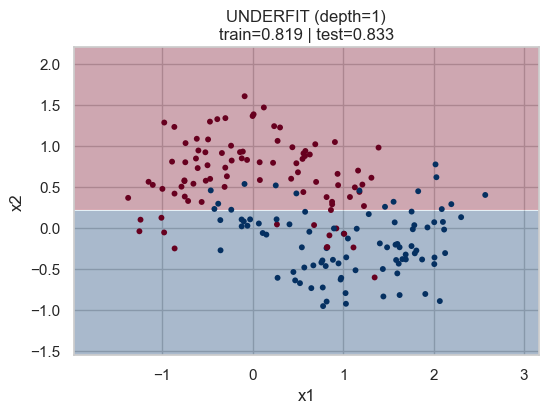

In [7]:
# MODEL UNDERFIT: max_depth=1 (decision stump)
clf = DecisionTreeClassifier(max_depth=1, random_state=42)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f'UNDERFIT | max_depth=1 | train={train_acc:.3f} | test={test_acc:.3f}')

plt.figure(figsize=(6, 4))
plot_decision_boundary(clf, X_test, y_test, title=f'UNDERFIT (depth=1)\ntrain={train_acc:.3f} | test={test_acc:.3f}')
plt.show()

## Kenapa ini underfit?
- Dengan `max_depth=1`, tree hanya boleh membuat **1 split**.
- Pola `make_moons` itu melengkung, jadi boundary lurus/sederhana biasanya tidak cukup.

### Cara memperbaiki
- Naikkan `max_depth` (mis. 4–6).
- Atau kurangi noise / tambah data agar pola lebih jelas.